# Train DF-FusionModel CAN v6 — Cải tiến ổn định + Vượt Baseline

**Cải tiến so với v5:**
- Tương thích rPPG v3 (DeepPhysCAN_v2: embed_dim=256, CAN_IMG_SIZE=96, DIFF_EPS=0.01)
- FUSION_PROJ_DIM=384 (rộng hơn), Fusion Head sâu hơn
- 3 giai đoạn train: Freeze → Fusion finetune → Full finetune
- Mixup cho cả fusion, WeightedRandomSampler cân bằng method
- Nhiều spatial frames hơn (6 train, 12 eval)
- TTA 3 chiến lược khi test


In [1]:
!pip install -q timm


In [2]:
import os, glob, time, random, copy, json, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA 4 ĐƯỜNG DẪN NÀY ====================
CACHE_DIR_SPATIAL = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
CACHE_DIR_RPPG    = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
SPATIAL_CKPT_PATH = "/kaggle/input/datasets/thinhphan1506/dffusion-trained-pth/spatial_transformer/spatial_transformer_best.pth"
RPPG_CKPT_PATH    = "/kaggle/input/datasets/thinhphan272/trained-dffusionmodel-rppg-pth/rppg_can_branch/rppg_can_best.pth"  # ← rPPG v3 mới
# ==============================================================

for p, n in [(CACHE_DIR_SPATIAL, "CACHE_DIR_SPATIAL"), (CACHE_DIR_RPPG, "CACHE_DIR_RPPG")]:
    assert os.path.isdir(p), f"Không tìm thấy {n}: {p}"
for p, n in [(SPATIAL_CKPT_PATH, "SPATIAL_CKPT_PATH"), (RPPG_CKPT_PATH, "RPPG_CKPT_PATH")]:
    assert os.path.exists(p), f"Không tìm thấy {n}: {p}"

# ==================== THAM SỐ ====================
SPATIAL_BACKBONE_NAME = "swin_base_patch4_window7_224"
SPATIAL_IMG_SIZE      = 224
N_SPATIAL_FRAMES_TRAIN = 6     # v5=4 → v6=6
N_SPATIAL_FRAMES_EVAL  = 12    # v5=8 → v6=12

# rPPG v3 params — PHẢI KHỚP với lúc train rPPG v3
CAN_IMG_SIZE        = 96       # v5=72 → v6=96 (khớp rPPG v3)
RPPG_CLIP_LEN_TRAIN = 48      # v5=32 → v6=48 (khớp rPPG v3)
RPPG_CLIP_LEN_EVAL  = 96      # v5=64 → v6=96
DIFF_EPS            = 0.01     # v5=1.0 → v6=0.01 (khớp rPPG v3)
MIN_FRAMES_RPPG     = 50

FUSION_PROJ_DIM     = 384      # v5=256 → v6=384 (rộng hơn cho cross-attention)
FUSION_HEADS        = 4
DROPOUT             = 0.25     # v5=0.2 → v6=0.25

BATCH_SIZE          = 4
GRAD_ACCUM          = 4        # effective batch = 16

EPOCHS_STAGE1       = 12       # Freeze cả 2 backbone, train cross-attention
EPOCHS_STAGE2       = 8        # Finetune fusion + rPPG backbone (spatial freeze)
EPOCHS_STAGE3       = 6        # Full finetune tất cả (LR cực nhỏ)
LR_FUSION           = 4e-4
LR_FINETUNE_RPPG    = 5e-6     # rPPG backbone đã tốt, chỉ tinh chỉnh nhẹ
LR_FINETUNE_ALL     = 1e-6     # full finetune cực nhỏ
WEIGHT_DECAY        = 1e-2

MIXUP_ALPHA         = 0.2
LABEL_SMOOTH_EPS    = 0.05
EMA_DECAY           = 0.999
PATIENCE            = 8
SEED                = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_DIR = "/kaggle/working/fusion_model"
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Device:", DEVICE)
print(f"CAN_IMG_SIZE={CAN_IMG_SIZE}, DIFF_EPS={DIFF_EPS}, FUSION_PROJ_DIM={FUSION_PROJ_DIM}")


Device: cuda
CAN_IMG_SIZE=96, DIFF_EPS=0.01, FUSION_PROJ_DIM=384


In [3]:
def load_manifest(cache_dir, old_prefix):
    m = pd.read_csv(os.path.join(cache_dir, "manifest_processed.csv"))
    m["out_dir"] = m["out_dir"].astype(str).str.replace(old_prefix, cache_dir, regex=False)
    return m

manifest_spatial = load_manifest(CACHE_DIR_SPATIAL, "/kaggle/working/ffpp_c23_cache")
manifest_spatial = manifest_spatial[manifest_spatial["status"].isin(["ok", "skip_exists"])]

manifest_rppg = load_manifest(CACHE_DIR_RPPG, "/kaggle/working/ffpp_c23_rppg_cache")
manifest_rppg = manifest_rppg[
    manifest_rppg["status"].isin(["ok", "skip_exists", "partial"]) & (manifest_rppg["n_frames"] >= MIN_FRAMES_RPPG)
]

# Kiểm tra trùng lặp
assert manifest_spatial.duplicated(subset=["video_id", "method"]).sum() == 0
assert manifest_rppg.duplicated(subset=["video_id", "method"]).sum() == 0
print("Duplicate check: OK")

# Merge theo (video_id, method)
merged = manifest_spatial[["video_id", "split", "label", "method", "out_dir"]].rename(
    columns={"out_dir": "spatial_dir"}
).merge(
    manifest_rppg[["video_id", "method", "out_dir", "label"]].rename(
        columns={"out_dir": "rppg_dir", "label": "label_rppg"}),
    on=["video_id", "method"], how="inner"
)
assert (merged["label"] != merged["label_rppg"]).sum() == 0
merged = merged.drop(columns=["label_rppg"])
assert merged.duplicated(subset=["video_id", "method"]).sum() == 0

print(f"Merged: {len(merged)}")
print(merged.groupby(["split", "label"])["video_id"].count().unstack(fill_value=0)
      .rename(columns={0: "real", 1: "fake"}))

train_df = merged[merged.split == "train"].reset_index(drop=True)
val_df   = merged[merged.split == "val"].reset_index(drop=True)
test_df  = merged[merged.split == "test"].reset_index(drop=True)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Duplicate check: OK
Merged: 5000
label  real  fake
split            
test    140   560
train   720  2880
val     140   560

Train: 3600 | Val: 700 | Test: 700


In [4]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_spatial_frame(path, augment=False):
    img = cv2.imread(path)
    if img is None: return torch.zeros(3, SPATIAL_IMG_SIZE, SPATIAL_IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SPATIAL_IMG_SIZE, SPATIAL_IMG_SIZE))
    if augment and random.random() < 0.5:
        img = img[:, ::-1, :].copy()
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()

def load_rppg_frame(path):
    img = cv2.imread(path)
    if img is None: return np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (CAN_IMG_SIZE, CAN_IMG_SIZE)).astype(np.float32)

def build_rppg_clip(paths, clip_len, train=True):
    n = len(paths)
    need = clip_len + 1
    start = random.randint(0, max(n - need, 0)) if (train and n >= need) else max(0, (n - need) // 2)
    apps, mots, prev = [], [], None
    for i in range(min(need, n)):
        fi = min(start + i, n - 1)
        img = load_rppg_frame(paths[fi])
        if prev is not None:
            c, p = img / 255.0, prev / 255.0
            apps.append(c)
            mots.append((c - p) / (c + p + DIFF_EPS))
        prev = img
    while len(apps) < clip_len:
        apps.append(apps[-1] if apps else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
        mots.append(mots[-1] if mots else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
    app_t = torch.from_numpy(np.stack(apps[:clip_len])).permute(0, 3, 1, 2).float()
    mot_t = torch.from_numpy(np.stack(mots[:clip_len])).permute(0, 3, 1, 2).float()
    return app_t, mot_t

class FusionDataset(Dataset):
    def __init__(self, df, train=True):
        self.rows = df.reset_index(drop=True)
        self.train = train
        self.n_sp  = N_SPATIAL_FRAMES_TRAIN if train else N_SPATIAL_FRAMES_EVAL
        self.rppg_len = RPPG_CLIP_LEN_TRAIN if train else RPPG_CLIP_LEN_EVAL

    def __len__(self): return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sp_files = sorted(glob.glob(os.path.join(row.spatial_dir, "*.jpg")))
        if self.train:
            chosen = random.sample(sp_files, min(self.n_sp, len(sp_files)))
        else:
            step = max(len(sp_files) // self.n_sp, 1)
            chosen = sp_files[::step][:self.n_sp]
        while len(chosen) < self.n_sp:
            chosen.append(chosen[-1] if chosen else sp_files[0])
        sp_frames = torch.stack([load_spatial_frame(p, augment=self.train) for p in chosen])

        rppg_files = sorted(glob.glob(os.path.join(row.rppg_dir, "*.jpg")))
        app, mot = build_rppg_clip(rppg_files, self.rppg_len, train=self.train)

        label = torch.tensor(row.label, dtype=torch.float32)
        if self.train:
            return sp_frames, app, mot, label
        return sp_frames, app, mot, label, row.video_id

train_ds = FusionDataset(train_df, train=True)
val_ds   = FusionDataset(val_df,   train=False)
test_ds  = FusionDataset(test_df,  train=False)

# Weighted sampler: cân bằng class + tăng NeuralTextures
class_counts = train_df["label"].value_counts().to_dict()
METHOD_WEIGHT = {"NeuralTextures": 2.0, "Face2Face": 1.3, "FaceSwap": 1.3, "Deepfakes": 1.0}

def get_weight(row):
    if row["label"] == 0: return 1.0 / class_counts[0]
    return (1.0 / class_counts[1]) * METHOD_WEIGHT.get(row.get("method", ""), 1.0)

weights = train_df.apply(get_weight, axis=1).values
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Method weights:", METHOD_WEIGHT)


Train: 3600 | Val: 700 | Test: 700
Method weights: {'NeuralTextures': 2.0, 'Face2Face': 1.3, 'FaceSwap': 1.3, 'Deepfakes': 1.0}


In [5]:
import timm

# ── Spatial Backbone (Swin Transformer) ──
class SpatialTransformerDetector(nn.Module):
    def __init__(self, backbone_name=SPATIAL_BACKBONE_NAME, pretrained=False, drop_path_rate=0.2):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0,
                                           drop_path_rate=drop_path_rate)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3), nn.Linear(256, 1))
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)

spatial_full = SpatialTransformerDetector(pretrained=False)
ckpt_sp = torch.load(SPATIAL_CKPT_PATH, map_location="cpu", weights_only=False)
spatial_full.load_state_dict(ckpt_sp["model_state"])
spatial_backbone = spatial_full.backbone
SPATIAL_EMBED_DIM = spatial_backbone.num_features
print(f"Spatial backbone loaded: embed_dim={SPATIAL_EMBED_DIM}")


# ── rPPG Backbone (DeepPhysCAN_v2 — khớp với rPPG v3) ──
class SqueezeExcitation(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                 nn.Linear(ch, ch // reduction), nn.ReLU(),
                                 nn.Linear(ch // reduction, ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.shortcut(x))

class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, 1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)

class TemporalTransformer(nn.Module):
    def __init__(self, dim, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 2,
            dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)
    def forward(self, x):
        B = x.shape[0]
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)
        return self.norm(self.encoder(self.pos_drop(x))[:, 0])

class DeepPhysCAN_v2(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.app_block1 = ResConvBlock(3, 48);   self.att_mask1 = AttentionMask(48)
        self.app_block2 = ResConvBlock(48, 96);  self.att_mask2 = AttentionMask(96)
        self.app_block3 = ResConvBlock(96, 192, use_se=True);  self.att_mask3 = AttentionMask(192)
        self.app_block4 = ResConvBlock(192, 256, use_se=True); self.att_mask4 = AttentionMask(256)
        self.mot_block1 = ResConvBlock(3, 48)
        self.mot_block2 = ResConvBlock(48, 96)
        self.mot_block3 = ResConvBlock(96, 192, use_se=True)
        self.mot_block4 = ResConvBlock(192, 256, use_se=True)
        self.pool = nn.AvgPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.frame_feat = nn.Sequential(nn.Linear(256, 256), nn.GELU(), nn.Dropout(dropout))
        self.temporal   = TemporalTransformer(dim=256, n_heads=4, n_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 1))
        self.embed_dim  = 256

    def _forward_pair(self, app, mot):
        a1 = self.app_block1(app); m1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1);  m2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2);  m3 = self.att_mask3(a3); a3 = self.pool(a3)
        a4 = self.app_block4(a3);  m4 = self.att_mask4(a4)
        v1 = self.mot_block1(mot) * m1; v1 = self.pool(v1)
        v2 = self.mot_block2(v1) * m2;  v2 = self.pool(v2)
        v3 = self.mot_block3(v2) * m3;  v3 = self.pool(v3)
        v4 = self.mot_block4(v3) * m4
        return self.frame_feat(self.gap(v4).flatten(1))

    def forward_features(self, app_clip, mot_clip):
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        CHUNK = 64
        if app_flat.shape[0] <= CHUNK:
            feats = self._forward_pair(app_flat, mot_flat)
        else:
            parts = []
            for i in range(0, app_flat.shape[0], CHUNK):
                parts.append(self._forward_pair(app_flat[i:i+CHUNK], mot_flat[i:i+CHUNK]))
            feats = torch.cat(parts, dim=0)
        return self.temporal(feats.reshape(B, T, -1))

rppg_backbone = DeepPhysCAN_v2()
ckpt_rppg = torch.load(RPPG_CKPT_PATH, map_location="cpu", weights_only=False)
rppg_backbone.load_state_dict(ckpt_rppg["model_state"])
RPPG_EMBED_DIM = rppg_backbone.embed_dim
print(f"rPPG backbone loaded (v2): embed_dim={RPPG_EMBED_DIM}")


# ── Cross-Attention Fusion v2 (deeper head + reliability gate) ──
class CrossAttentionFusion_v2(nn.Module):
    def __init__(self, spatial_dim, rppg_dim, proj_dim=FUSION_PROJ_DIM,
                 n_heads=FUSION_HEADS, dropout=DROPOUT):
        super().__init__()
        self.spatial_proj = nn.Sequential(nn.Linear(spatial_dim, proj_dim), nn.LayerNorm(proj_dim))
        self.rppg_proj    = nn.Sequential(nn.Linear(rppg_dim,   proj_dim), nn.LayerNorm(proj_dim))

        self.attn_s2r = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_r2s = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)

        # FFN sau attention (giúp fusion sâu hơn)
        self.ffn_s = nn.Sequential(nn.Linear(proj_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ffn_r = nn.Sequential(nn.Linear(proj_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.norm_s = nn.LayerNorm(proj_dim)
        self.norm_r = nn.LayerNorm(proj_dim)

        self.reliability_gate = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(proj_dim // 2, 1), nn.Sigmoid())

        # Classifier sâu hơn: 3 layers thay vì 2
        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim * 2),
            nn.Linear(proj_dim * 2, proj_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(proj_dim // 2, 64), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1))

    def forward(self, spatial_embed, rppg_embed, return_gate=False):
        s = self.spatial_proj(spatial_embed).unsqueeze(1)
        r = self.rppg_proj(rppg_embed).unsqueeze(1)

        s_att, _ = self.attn_s2r(s, r, r)
        r_att, _ = self.attn_r2s(r, s, s)

        # Post-attention FFN + residual
        s_out = self.norm_s(s.squeeze(1) + self.ffn_s(s_att.squeeze(1)))
        r_out = self.norm_r(r.squeeze(1) + self.ffn_r(r_att.squeeze(1)))

        gate = self.reliability_gate(torch.cat([s_out, r_out], dim=1))
        fused = torch.cat([s_out, gate * r_out], dim=1)

        logits = self.classifier(fused).squeeze(-1)
        if return_gate: return logits, gate.squeeze(-1)
        return logits


class DeepfakeFusionModel(nn.Module):
    def __init__(self, sp_backbone, rppg_backbone, sp_dim, rppg_dim):
        super().__init__()
        self.spatial_backbone = sp_backbone
        self.rppg_backbone    = rppg_backbone
        self.fusion           = CrossAttentionFusion_v2(sp_dim, rppg_dim)
        self.spatial_frozen = True
        self.rppg_frozen    = True

    def set_trainable(self, spatial_tr, rppg_tr):
        for p in self.spatial_backbone.parameters(): p.requires_grad = spatial_tr
        for p in self.rppg_backbone.parameters():    p.requires_grad = rppg_tr
        self.spatial_frozen = not spatial_tr
        self.rppg_frozen    = not rppg_tr

    def train(self, mode=True):
        super().train(mode)
        if self.spatial_frozen: self.spatial_backbone.eval()
        if self.rppg_frozen:    self.rppg_backbone.eval()
        return self

    def encode_spatial(self, frames):
        B, N = frames.shape[:2]
        flat = frames.reshape(B * N, *frames.shape[2:])
        ctx = torch.no_grad() if self.spatial_frozen else torch.enable_grad()
        with ctx:
            feats = self.spatial_backbone(flat)
        return feats.reshape(B, N, -1).mean(1)

    def encode_rppg(self, app, mot):
        ctx = torch.no_grad() if self.rppg_frozen else torch.enable_grad()
        with ctx:
            return self.rppg_backbone.forward_features(app, mot)

    def forward(self, sp_frames, app, mot, return_gate=False):
        s = self.encode_spatial(sp_frames)
        r = self.encode_rppg(app, mot)
        return self.fusion(s, r, return_gate=return_gate)


fusion_model = DeepfakeFusionModel(spatial_backbone, rppg_backbone, SPATIAL_EMBED_DIM, RPPG_EMBED_DIM).to(DEVICE)
fusion_model.set_trainable(False, False)
n_tr = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
n_all = sum(p.numel() for p in fusion_model.parameters())
print(f"Total: {n_all/1e6:.2f}M | Trainable (Stage 1): {n_tr/1e6:.2f}M")


Spatial backbone loaded: embed_dim=1024
rPPG backbone loaded (v2): embed_dim=256
Total: 93.79M | Trainable (Stage 1): 2.28M


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    return far, frr, cm

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc_val = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, _ = calc_far_frr(y_true, y_score, threshold=eer_thr)
    acc_eer = accuracy_score(y_true, (y_score >= eer_thr).astype(int))
    return {"acc": acc, "auc": auc_val, "eer": eer,
            "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
            "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "acc_at_eer": acc_eer}


In [7]:
def smooth_labels(labels, eps=LABEL_SMOOTH_EPS):
    return labels * (1 - eps) + 0.5 * eps

def mixup_data(sp, app, mot, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0: return sp, app, mot, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(sp.size(0), device=sp.device)
    return lam*sp + (1-lam)*sp[idx], lam*app + (1-lam)*app[idx], lam*mot + (1-lam)*mot[idx], labels, labels[idx], lam

class ModelEma:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema_model = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema_model.parameters(): p.requires_grad_(False)
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema_model.state_dict().items():
            m = msd[k].detach()
            if v.dtype.is_floating_point: v.mul_(self.decay).add_(m, alpha=1-self.decay)
            else: v.copy_(m)

@torch.no_grad()
def evaluate(eval_model, loader, criterion):
    eval_model.eval()
    y_true, y_score, losses = [], [], []
    for sp, app, mot, label, _ in loader:
        sp, app, mot, label = sp.to(DEVICE), app.to(DEVICE), mot.to(DEVICE), label.to(DEVICE)
        logits = eval_model(sp, app, mot)
        losses.append(criterion(logits, label).item())
        y_score.append(torch.sigmoid(logits).item())
        y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics

criterion = nn.BCEWithLogitsLoss()
ema = ModelEma(fusion_model, decay=EMA_DECAY)

BEST_PATH = os.path.join(OUT_DIR, "fusion_model_best.pth")
history = {"stage": [], "epoch": [], "train_loss": [],
           "val_loss_raw": [], "val_auc_raw": [], "val_eer_raw": [], "val_acc_raw": [],
           "val_loss_ema": [], "val_auc_ema": [], "val_eer_ema": [], "val_acc_ema": [],
           "used_ema": []}
best_val_auc = -1
global_epoch = 0
MIN_EPOCHS = {"stage1_freeze": 5, "stage2_rppg_ft": 3, "stage3_full_ft": 2}

stages = [
    ("stage1_freeze",   EPOCHS_STAGE1, False, False, LR_FUSION,  0.0,             0.0),
    ("stage2_rppg_ft",  EPOCHS_STAGE2, False, True,  LR_FUSION*0.5, 0.0,          LR_FINETUNE_RPPG),
    ("stage3_full_ft",  EPOCHS_STAGE3, True,  True,  LR_FINETUNE_ALL*10, LR_FINETUNE_ALL, LR_FINETUNE_ALL),
]

for stage_name, n_epochs, sp_tr, rppg_tr, lr_fus, lr_sp, lr_rppg in stages:
    fusion_model.set_trainable(sp_tr, rppg_tr)
    n_trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"=== {stage_name} ({n_epochs} epochs) | trainable: {n_trainable/1e6:.2f}M ===")
    print(f"{'='*60}")

    patience_ctr = 0
    min_ep = MIN_EPOCHS.get(stage_name, 3)

    optimizer = torch.optim.AdamW([
        {"params": fusion_model.fusion.parameters(), "lr": lr_fus},
        {"params": fusion_model.spatial_backbone.parameters(), "lr": lr_sp},
        {"params": fusion_model.rppg_backbone.parameters(), "lr": lr_rppg},
    ], weight_decay=WEIGHT_DECAY)

    n_opt_steps = max(len(train_loader) // GRAD_ACCUM, 1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs * n_opt_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    for epoch in range(1, n_epochs + 1):
        global_epoch += 1
        fusion_model.train()
        running_loss, n_batches = 0.0, 0
        t0 = time.time()
        optimizer.zero_grad()

        for step, (sp, app, mot, label) in enumerate(train_loader):
            sp, app, mot, label = sp.to(DEVICE), app.to(DEVICE), mot.to(DEVICE), label.to(DEVICE)

            # Mixup (chỉ stage 1 & 2, stage 3 tắt để ổn định)
            if stage_name != "stage3_full_ft" and MIXUP_ALPHA > 0:
                sp, app, mot, y_a, y_b, lam = mixup_data(sp, app, mot, label)
                y_a, y_b = smooth_labels(y_a), smooth_labels(y_b)
            else:
                y_a = smooth_labels(label); y_b = y_a; lam = 1.0

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = fusion_model(sp, app, mot)
                loss = (lam * criterion(logits, y_a) + (1-lam) * criterion(logits, y_b)) / GRAD_ACCUM

            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(); scheduler.step()
                ema.update(fusion_model)

            running_loss += loss.item() * GRAD_ACCUM
            n_batches += 1

        train_loss = running_loss / max(n_batches, 1)
        val_raw = evaluate(fusion_model, val_loader, criterion)
        val_ema = evaluate(ema.ema_model, val_loader, criterion)
        use_ema = val_ema["auc"] >= val_raw["auc"]
        val = val_ema if use_ema else val_raw

        history["stage"].append(stage_name); history["epoch"].append(global_epoch)
        history["train_loss"].append(train_loss)
        history["val_loss_raw"].append(val_raw["loss"]); history["val_auc_raw"].append(val_raw["auc"])
        history["val_eer_raw"].append(val_raw["eer"]);   history["val_acc_raw"].append(val_raw["acc"])
        history["val_loss_ema"].append(val_ema["loss"]); history["val_auc_ema"].append(val_ema["auc"])
        history["val_eer_ema"].append(val_ema["eer"]);   history["val_acc_ema"].append(val_ema["acc"])
        history["used_ema"].append(use_ema)

        dt = time.time() - t0
        print(f"[{stage_name} {epoch:02d}/{n_epochs}] loss={train_loss:.4f} "
              f"auc_raw={val_raw['auc']:.4f} auc_ema={val_ema['auc']:.4f} "
              f"eer={val['eer']:.4f} | {'EMA' if use_ema else 'raw'} | {dt:.0f}s")

        if val["auc"] > best_val_auc:
            best_val_auc = val["auc"]; patience_ctr = 0
            save_st = ema.ema_model.state_dict() if use_ema else fusion_model.state_dict()
            torch.save({"model_state": save_st, "epoch": global_epoch, "stage": stage_name,
                        "used_ema": use_ema, "val_metrics": val,
                        "spatial_embed_dim": SPATIAL_EMBED_DIM, "rppg_embed_dim": RPPG_EMBED_DIM}, BEST_PATH)
            print(f"    -> Best (val_auc={best_val_auc:.4f})")
        else:
            patience_ctr += 1
            if epoch >= min_ep and patience_ctr >= PATIENCE:
                print(f"Early stopping @ {stage_name} epoch {epoch}")
                break

pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print(f"\nSaved train_history.csv | Best val_auc: {best_val_auc:.4f}")



=== stage1_freeze (12 epochs) | trainable: 2.28M ===
[stage1_freeze 01/12] loss=0.2280 auc_raw=0.9852 auc_ema=0.9926 eer=0.0357 | EMA | 1037s
    -> Best (val_auc=0.9926)
[stage1_freeze 02/12] loss=0.2143 auc_raw=0.9858 auc_ema=0.9923 eer=0.0357 | EMA | 960s
[stage1_freeze 03/12] loss=0.2162 auc_raw=0.9877 auc_ema=0.9920 eer=0.0357 | EMA | 893s
[stage1_freeze 04/12] loss=0.2145 auc_raw=0.9848 auc_ema=0.9902 eer=0.0357 | EMA | 858s
[stage1_freeze 05/12] loss=0.2072 auc_raw=0.9799 auc_ema=0.9873 eer=0.0375 | EMA | 828s
[stage1_freeze 06/12] loss=0.2163 auc_raw=0.9796 auc_ema=0.9852 eer=0.0393 | EMA | 854s
[stage1_freeze 07/12] loss=0.2100 auc_raw=0.9781 auc_ema=0.9816 eer=0.0357 | EMA | 881s
[stage1_freeze 08/12] loss=0.2085 auc_raw=0.9871 auc_ema=0.9801 eer=0.0339 | raw | 851s
[stage1_freeze 09/12] loss=0.2098 auc_raw=0.9805 auc_ema=0.9800 eer=0.0375 | raw | 870s
Early stopping @ stage1_freeze epoch 9

=== stage2_rppg_ft (8 epochs) | trainable: 7.05M ===
[stage2_rppg_ft 01/8] loss=0.21

In [8]:
@torch.no_grad()
def evaluate_with_tta(model, loader, use_tta=True):
    model.eval()
    y_true, y_score = [], []
    for sp, app, mot, label, _ in tqdm(loader, desc="Test"):
        sp, app, mot = sp.to(DEVICE), app.to(DEVICE), mot.to(DEVICE)
        logits_list = [model(sp, app, mot)]
        if use_tta:
            # TTA 1: flip horizontal
            logits_list.append(model(torch.flip(sp, [4]), torch.flip(app, [4]), torch.flip(mot, [4])))
            # TTA 2: nửa đầu clip
            T = app.shape[1]; half = max(T // 2, 1)
            logits_list.append(model(sp[:, :sp.shape[1]//2+1], app[:, :half], mot[:, :half]))
        prob = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(prob.item()); y_true.append(label.item())
    return np.array(y_true), np.array(y_score)

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
fusion_model.load_state_dict(ckpt["model_state"])
print(f"Loaded best: epoch={ckpt['epoch']} stage={ckpt['stage']} (val_auc={ckpt['val_metrics']['auc']:.4f})")

y_true, y_score = evaluate_with_tta(fusion_model, test_loader, use_tta=True)
test_m = calc_metrics(y_true, y_score)

print("\n=== KẾT QUẢ TEST — DF-FusionModel CAN v6 + TTA ===")
print(f"Accuracy : {test_m['acc']*100:.2f}%")
print(f"AUC      : {test_m['auc']*100:.2f}%")
print(f"EER      : {test_m['eer']*100:.2f}%")
print(f"FAR@0.5  : {test_m['far_at_0.5']*100:.2f}%")
print(f"FRR@0.5  : {test_m['frr_at_0.5']*100:.2f}%")

cm = test_m["cm_at_0.5"]
print(f"\nConfusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

# Breakdown by method
test_ordered = test_df.reset_index(drop=True)
rows = []
real_mask = test_ordered["label"].values == 0
for method in sorted(test_ordered.loc[~real_mask, "method"].unique()):
    mm = test_ordered["method"].values == method
    sel = real_mask | mm
    m = calc_metrics(y_true[sel], y_score[sel])
    rows.append({"method": method, "auc": m["auc"], "eer": m["eer"]})
bd = pd.DataFrame(rows).sort_values("auc")
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== Breakdown ===")
print(bd.to_string(index=False))

print("\n=== So sánh với Baseline ===")
comp = pd.DataFrame([
    {"model": "Spatial only",     "acc": 0.9657, "auc": 0.9926, "eer": 0.0286},
    {"model": "rPPG only (v3)",   "acc": "TBD",  "auc": "TBD",  "eer": "TBD"},
    {"model": "Fusion CAN v6",    "acc": test_m["acc"], "auc": test_m["auc"], "eer": test_m["eer"]},
])
print(comp.to_string(index=False))
comp.to_csv(os.path.join(OUT_DIR, "ablation_table_A.csv"), index=False)


Loaded best: epoch=1 stage=stage1_freeze (val_auc=0.9926)


Test: 100%|██████████| 700/700 [08:32<00:00,  1.37it/s]


=== KẾT QUẢ TEST — DF-FusionModel CAN v6 + TTA ===
Accuracy : 96.71%
AUC      : 99.49%
EER      : 2.32%
FAR@0.5  : 2.32%
FRR@0.5  : 7.14%

Confusion Matrix: TN=130 FP=10 FN=13 TP=547

=== Breakdown ===
        method      auc      eer
NeuralTextures 0.988827 0.057143
     Face2Face 0.994643 0.021429
      FaceSwap 0.997143 0.021429
     Deepfakes 0.999133 0.014286

=== So sánh với Baseline ===
         model       acc       auc       eer
  Spatial only    0.9657    0.9926    0.0286
rPPG only (v3)       TBD       TBD       TBD
 Fusion CAN v6  0.967143  0.994936  0.023214


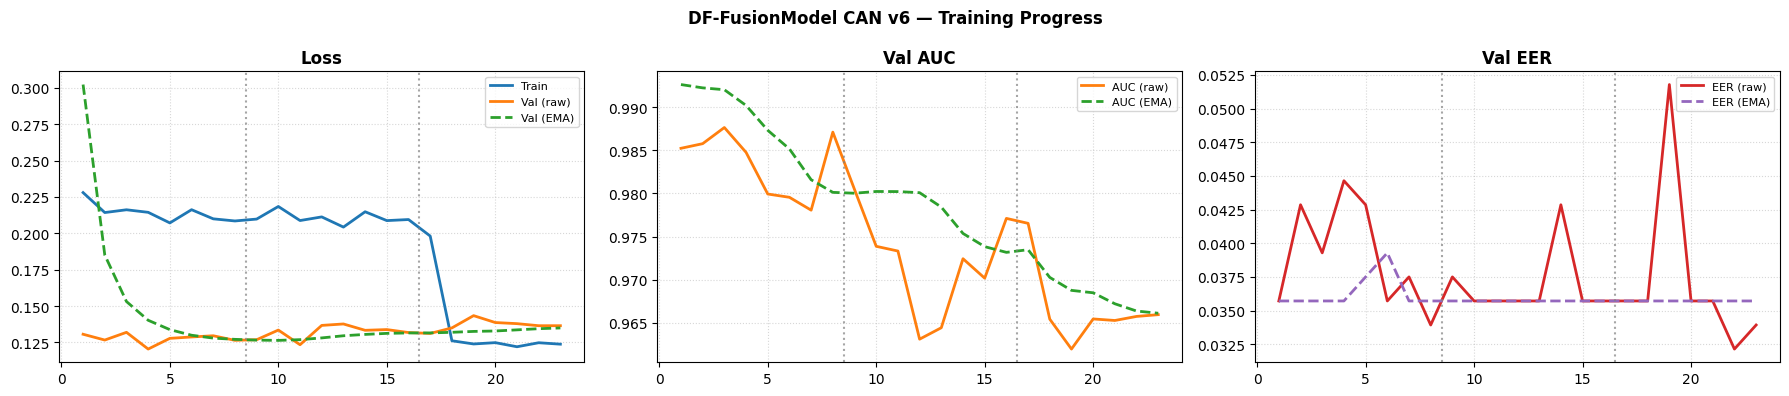

Epochs per stage:
stage
stage1_freeze     9
stage2_rppg_ft    8
stage3_full_ft    6
Name: epoch, dtype: int64


In [9]:
import matplotlib.pyplot as plt

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))

# Detect stage boundaries
stage_changes = hist_df["stage"].ne(hist_df["stage"].shift()).cumsum()
boundaries = []
for i in range(1, stage_changes.max()):
    idx = stage_changes[stage_changes == i + 1].index
    if len(idx) > 0:
        boundaries.append(idx[0] - 0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train", color="tab:blue", lw=2)
axes[0].plot(hist_df["epoch"], hist_df["val_loss_raw"], label="Val (raw)", color="tab:orange", lw=2)
axes[0].plot(hist_df["epoch"], hist_df["val_loss_ema"], label="Val (EMA)", color="tab:green", lw=2, ls="--")
for b in boundaries: axes[0].axvline(b, color="gray", ls=":", alpha=0.7)
axes[0].set_title("Loss", fontweight="bold"); axes[0].legend(fontsize=8); axes[0].grid(True, ls=":", alpha=0.5)

axes[1].plot(hist_df["epoch"], hist_df["val_auc_raw"], label="AUC (raw)", color="tab:orange", lw=2)
axes[1].plot(hist_df["epoch"], hist_df["val_auc_ema"], label="AUC (EMA)", color="tab:green", lw=2, ls="--")
for b in boundaries: axes[1].axvline(b, color="gray", ls=":", alpha=0.7)
axes[1].set_title("Val AUC", fontweight="bold"); axes[1].legend(fontsize=8); axes[1].grid(True, ls=":", alpha=0.5)

axes[2].plot(hist_df["epoch"], hist_df["val_eer_raw"], label="EER (raw)", color="tab:red", lw=2)
axes[2].plot(hist_df["epoch"], hist_df["val_eer_ema"], label="EER (EMA)", color="tab:purple", lw=2, ls="--")
for b in boundaries: axes[2].axvline(b, color="gray", ls=":", alpha=0.7)
axes[2].set_title("Val EER", fontweight="bold"); axes[2].legend(fontsize=8); axes[2].grid(True, ls=":", alpha=0.5)

plt.suptitle("DF-FusionModel CAN v6 — Training Progress", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()

print("Epochs per stage:")
print(hist_df.groupby("stage")["epoch"].count())
